In [1]:
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Verdana'], 
    'font.size': 16,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})


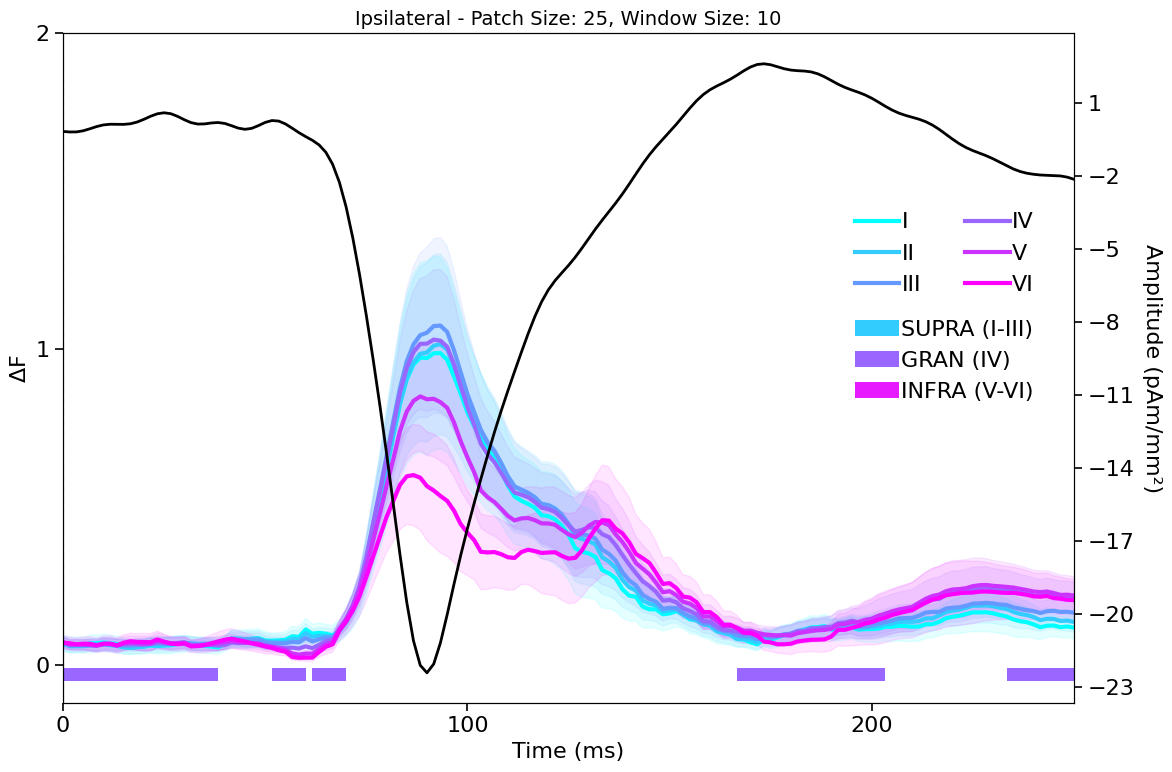

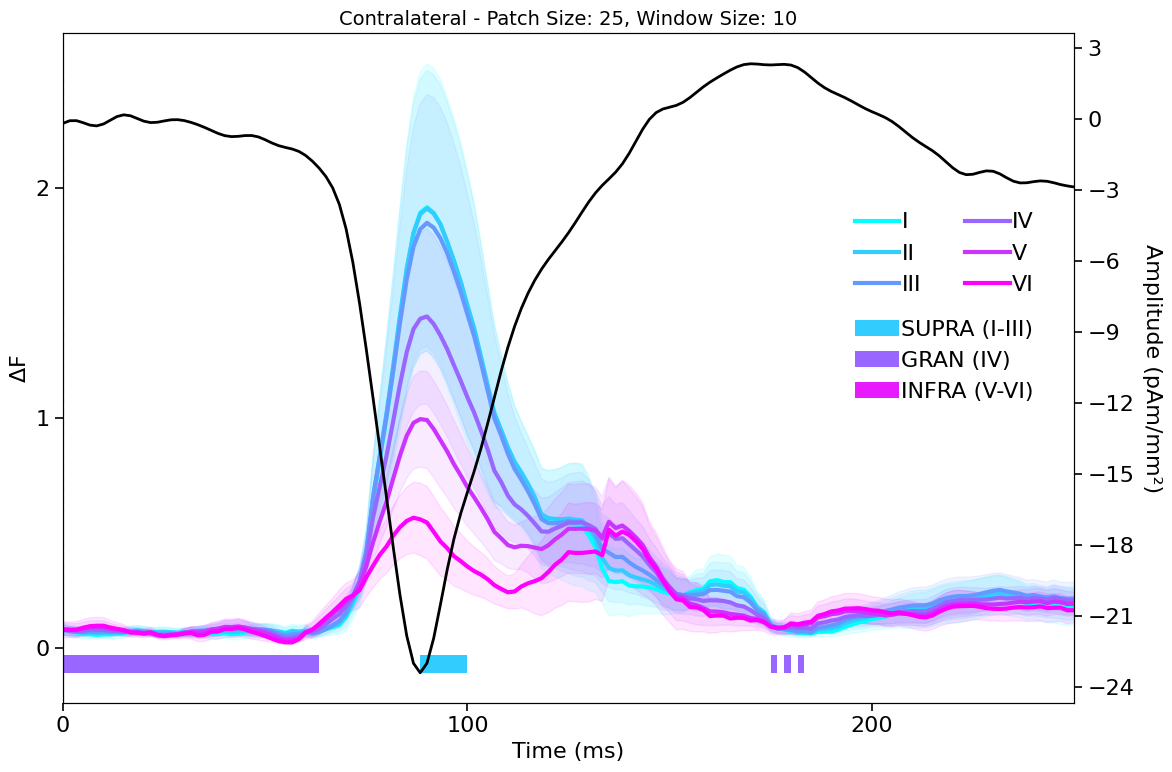

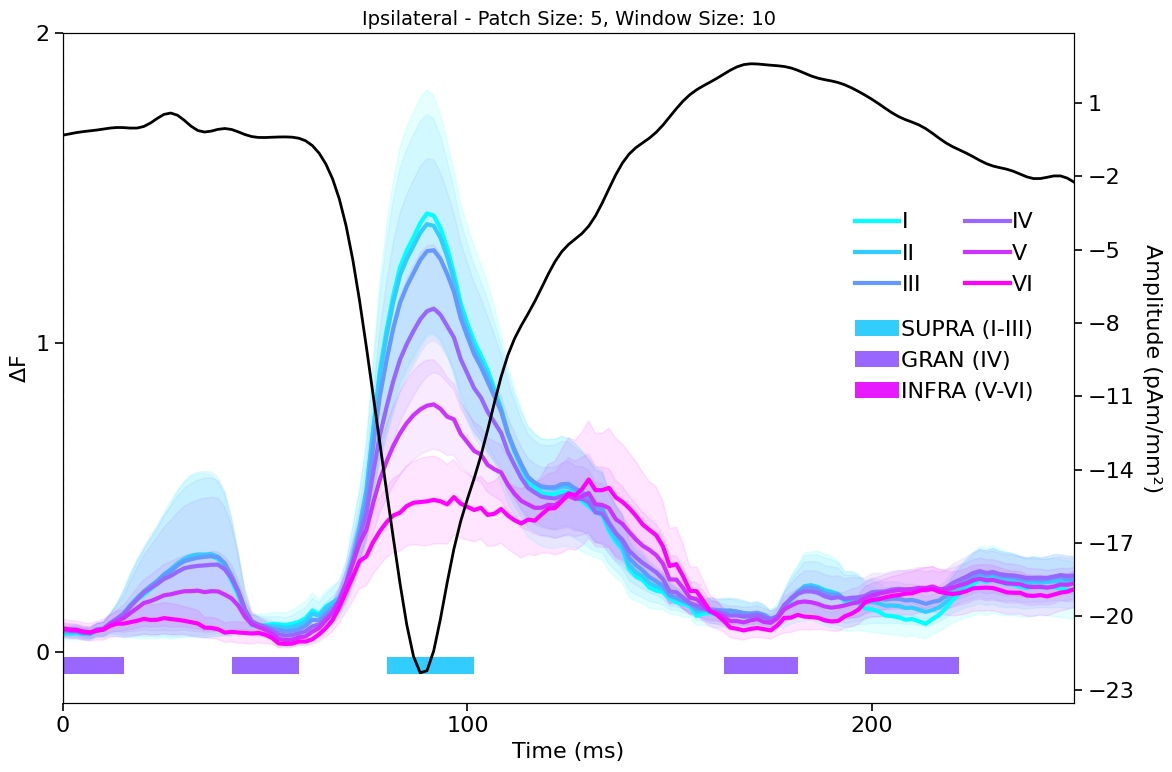

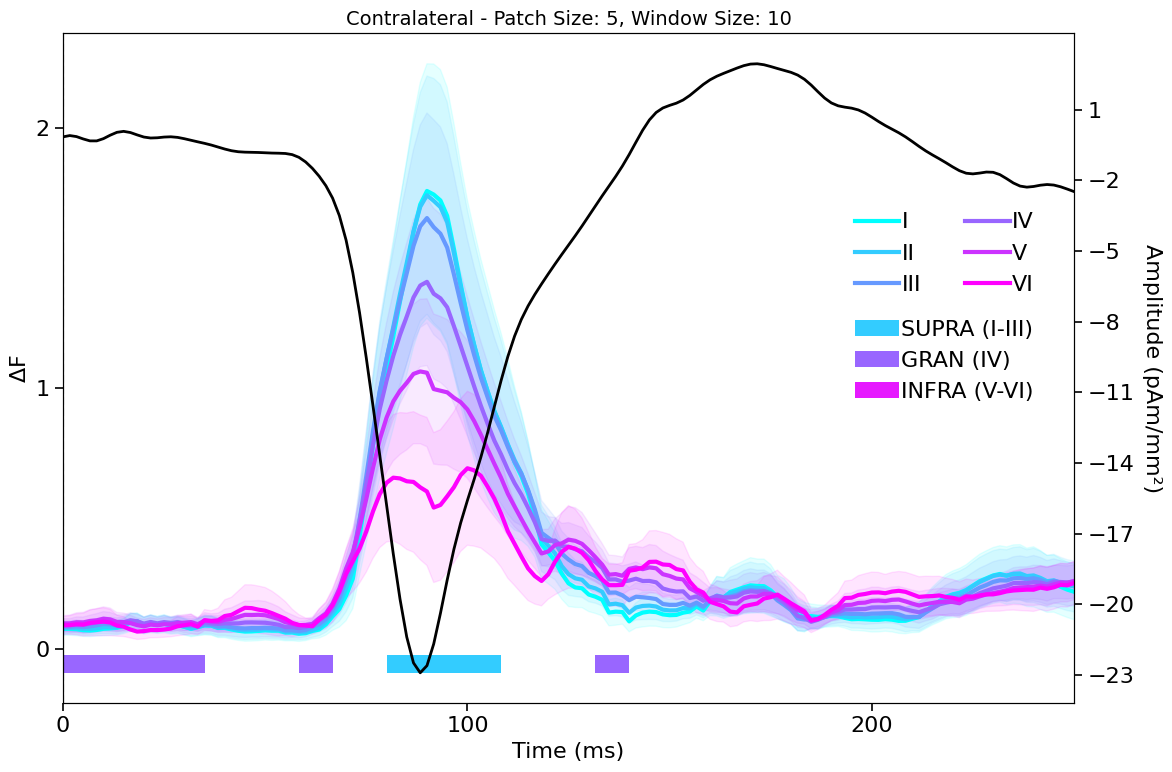

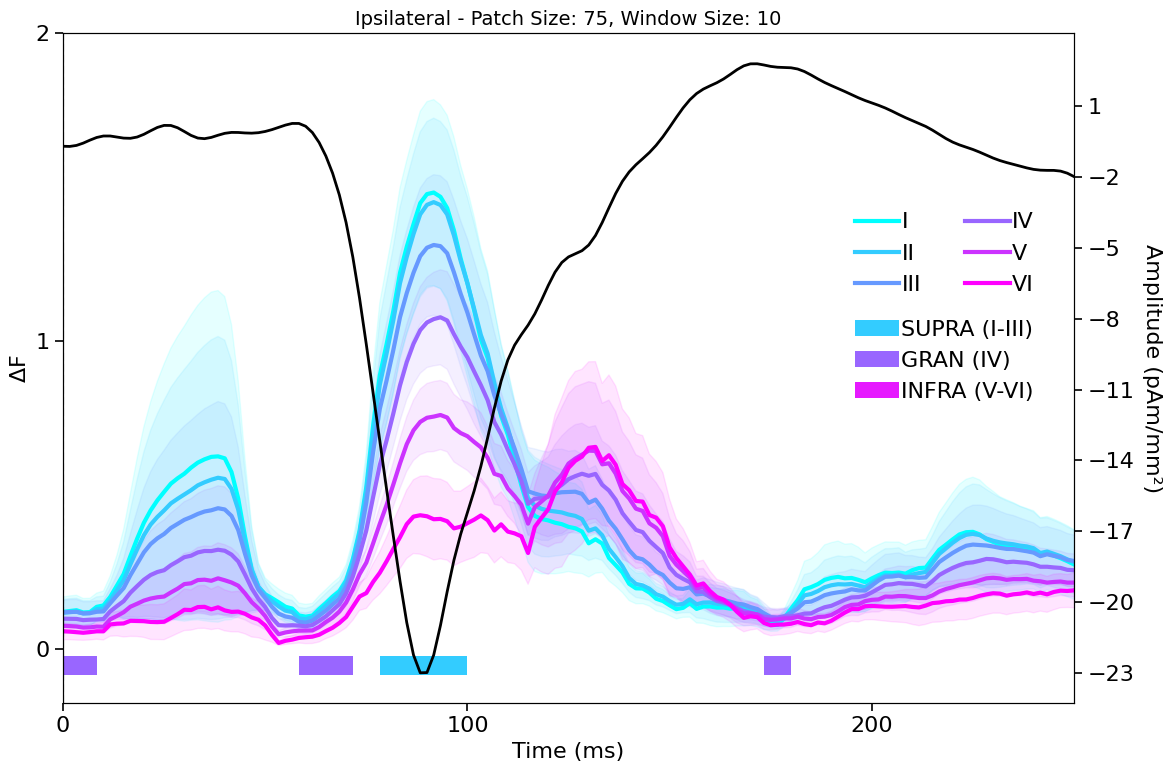

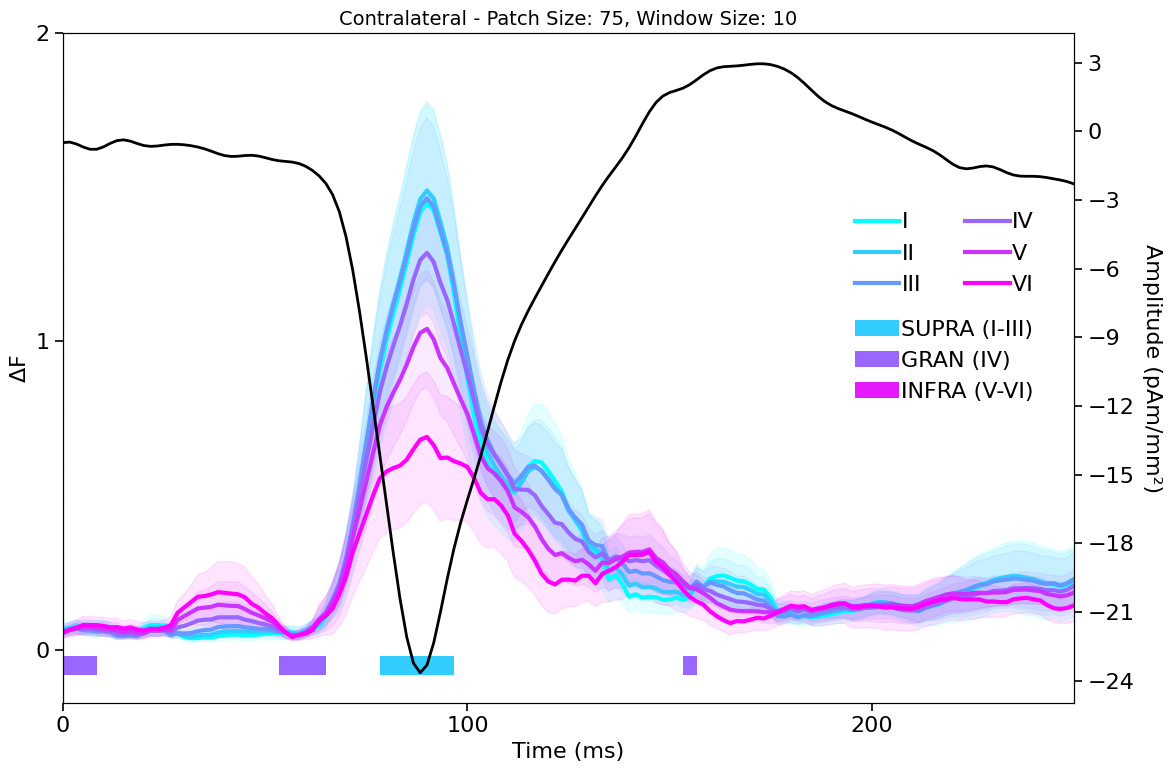

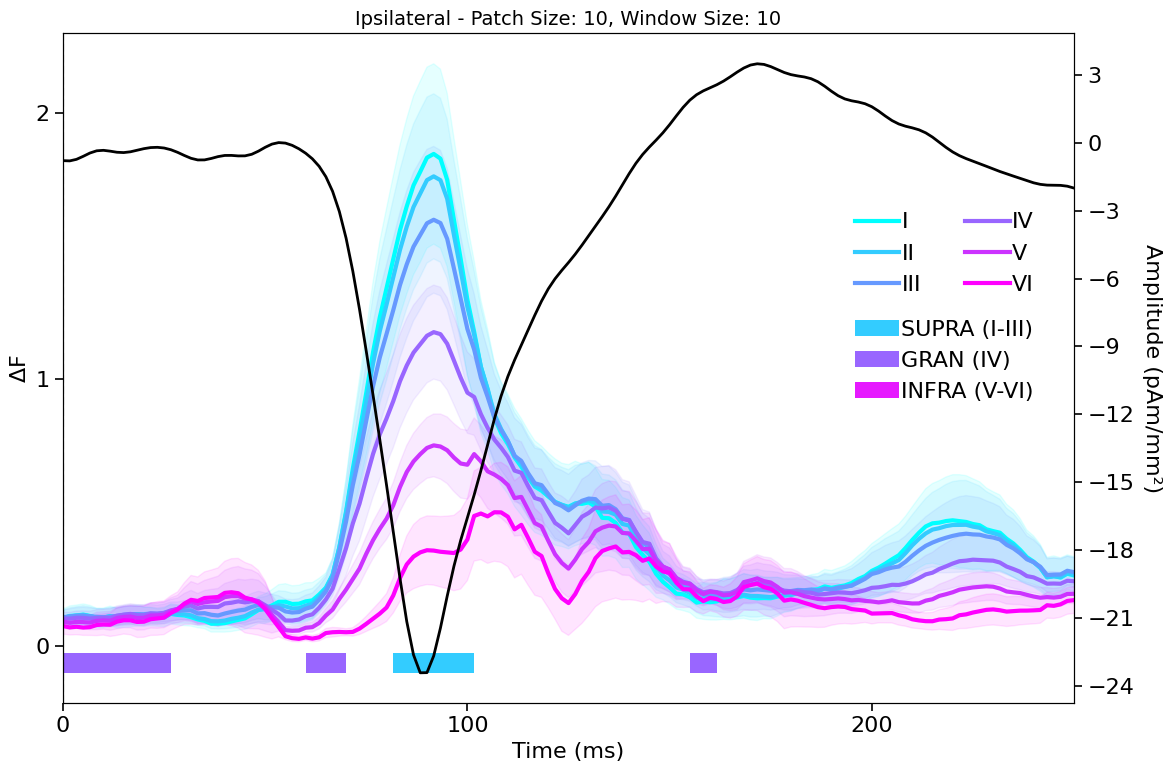

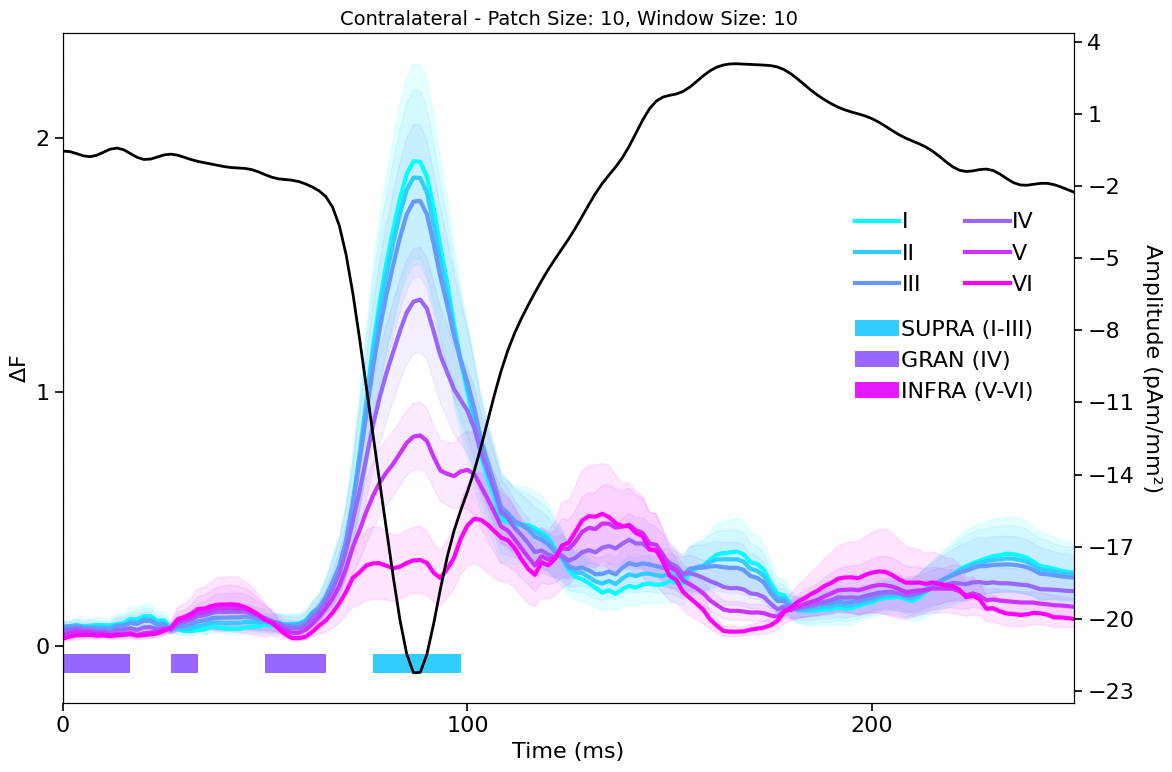

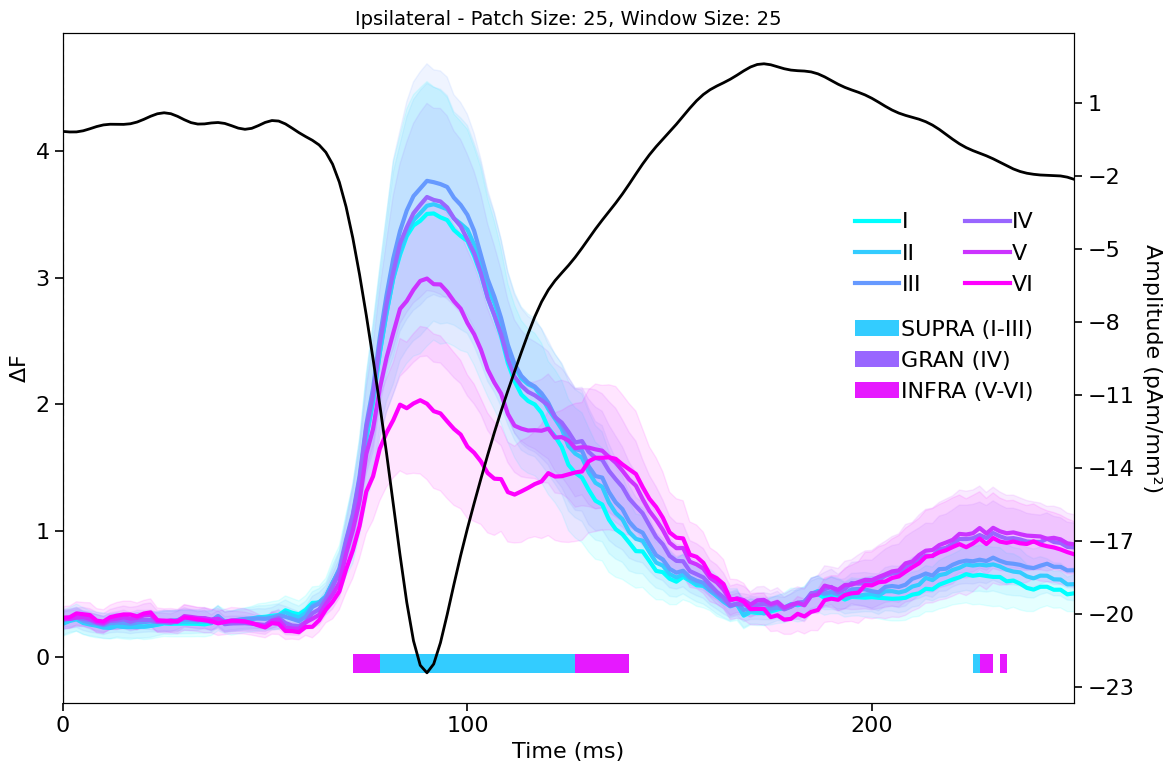

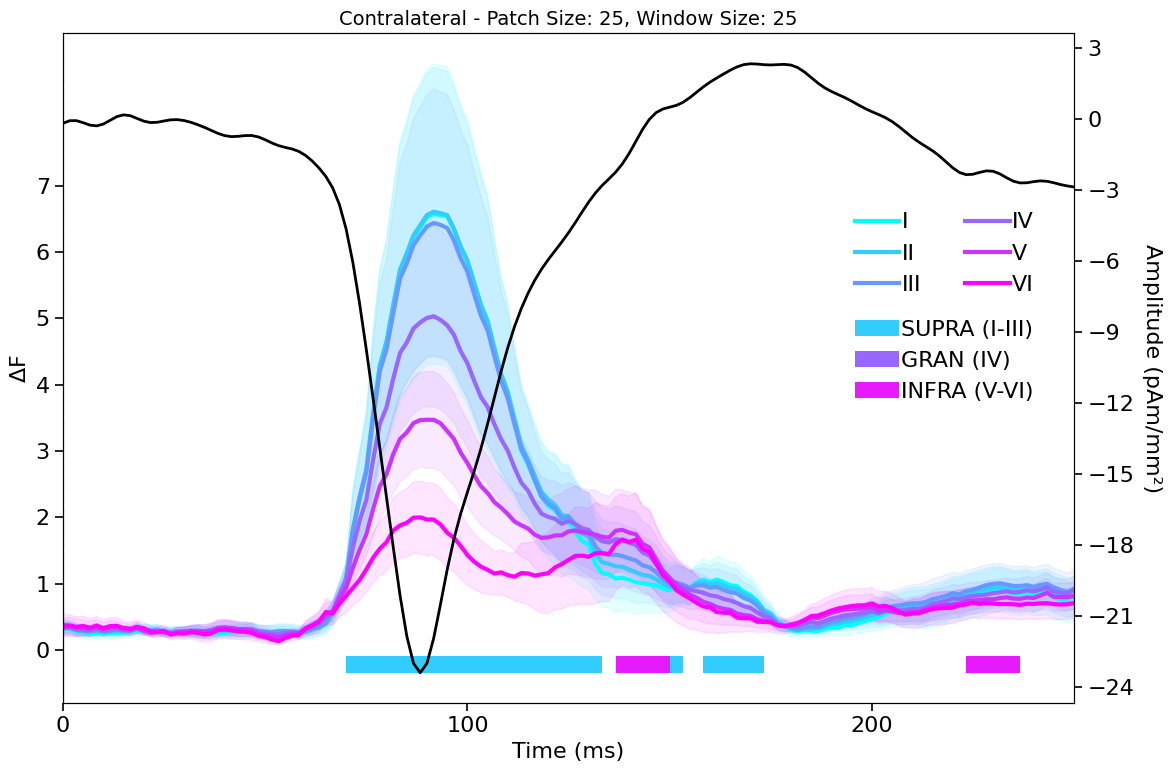

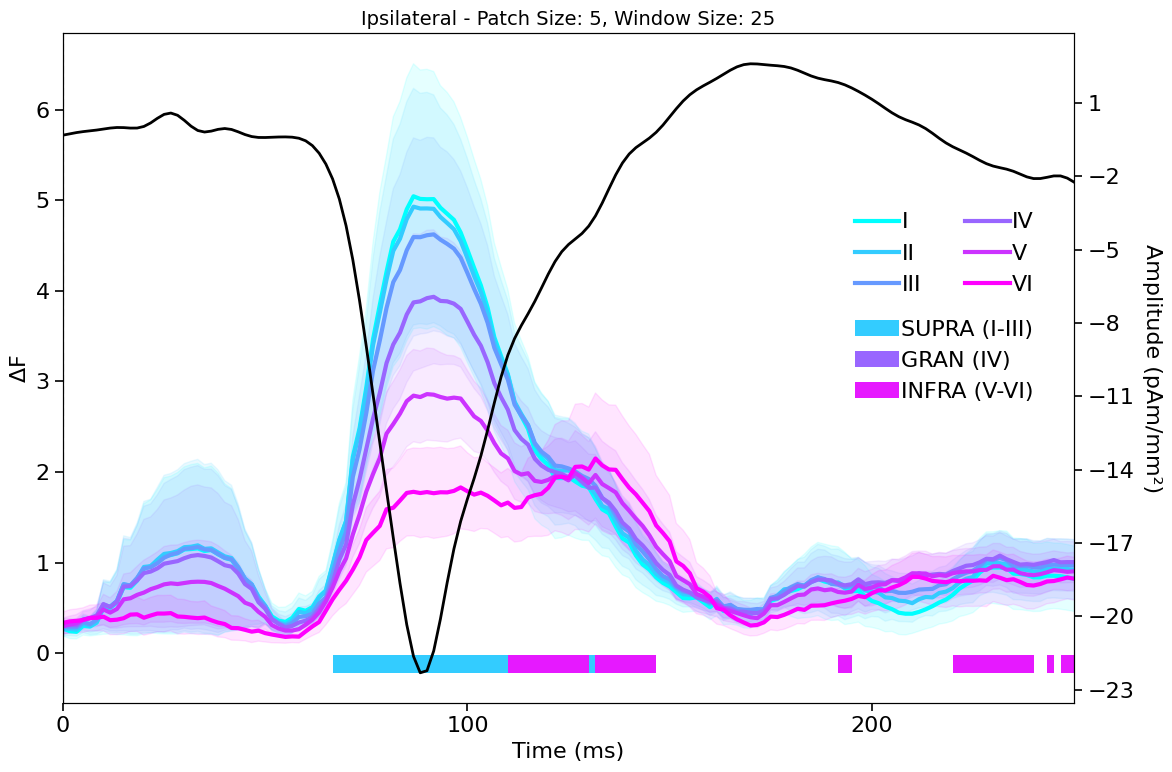

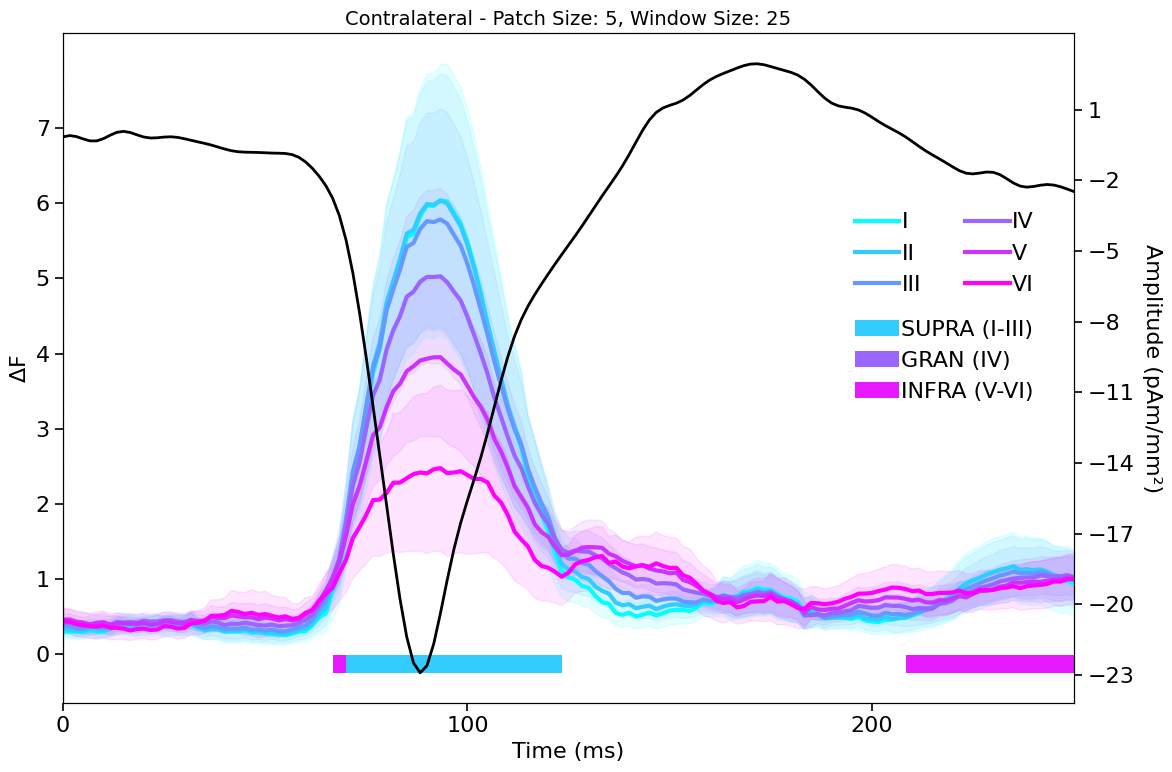

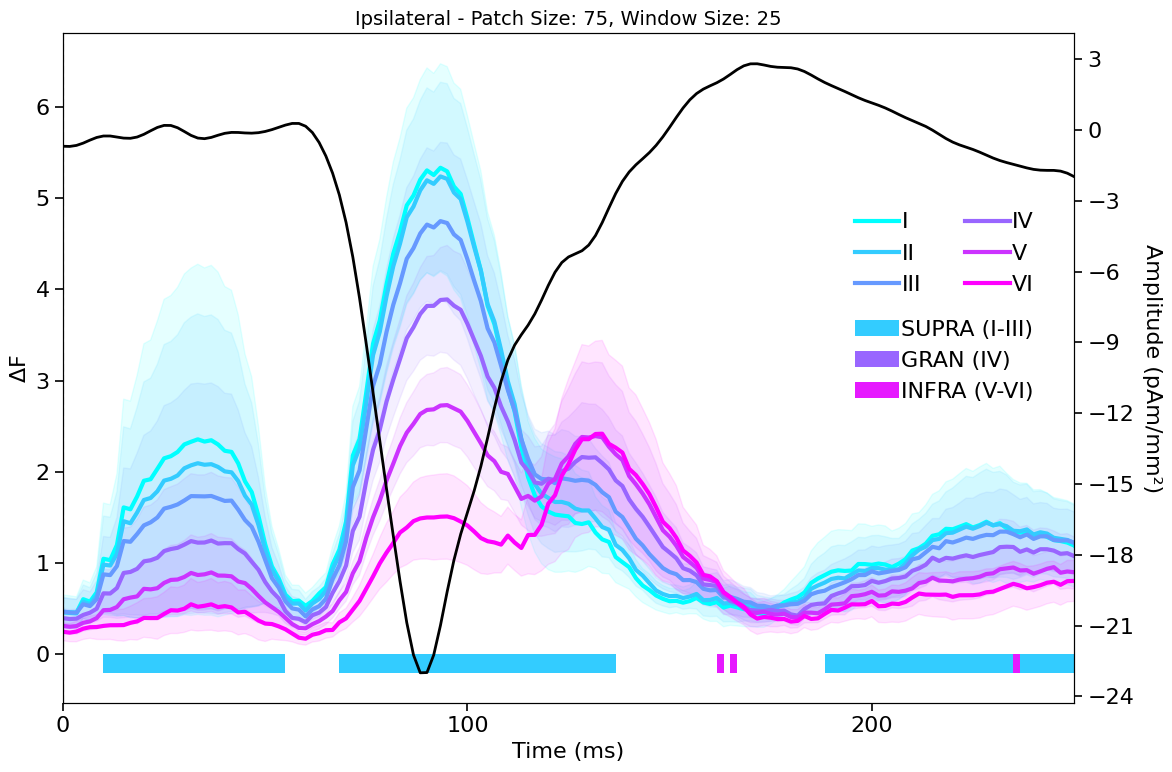

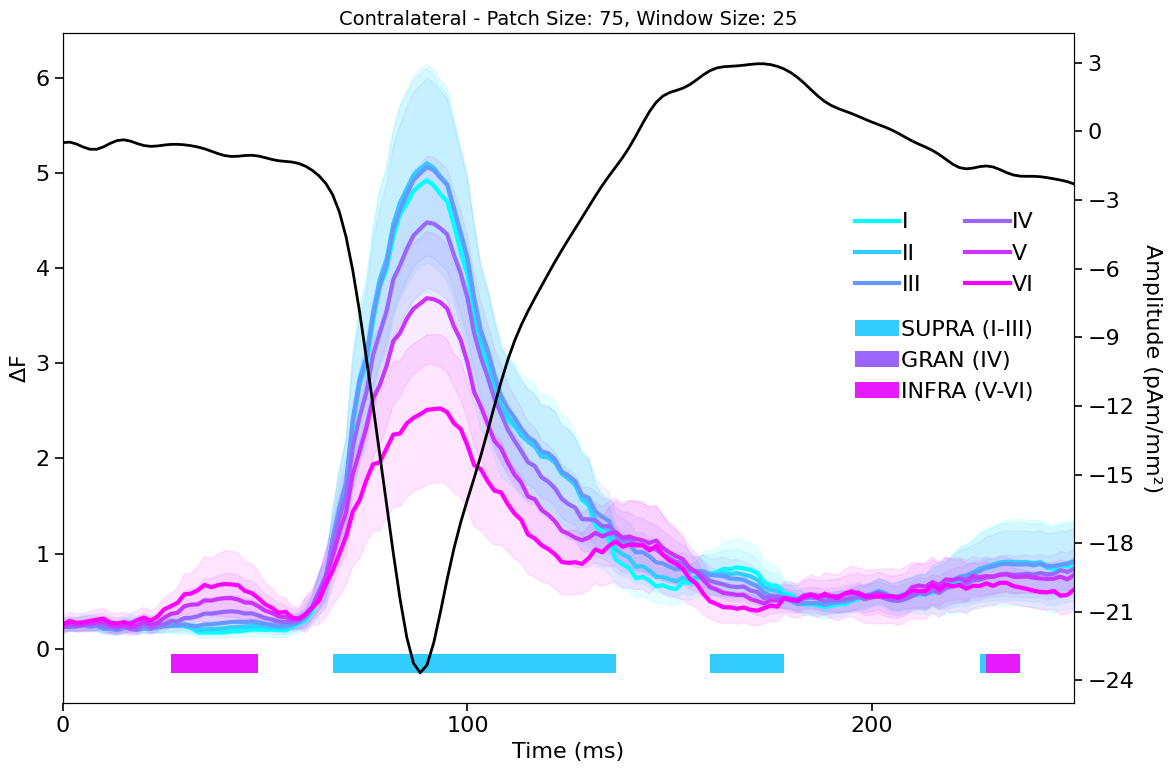

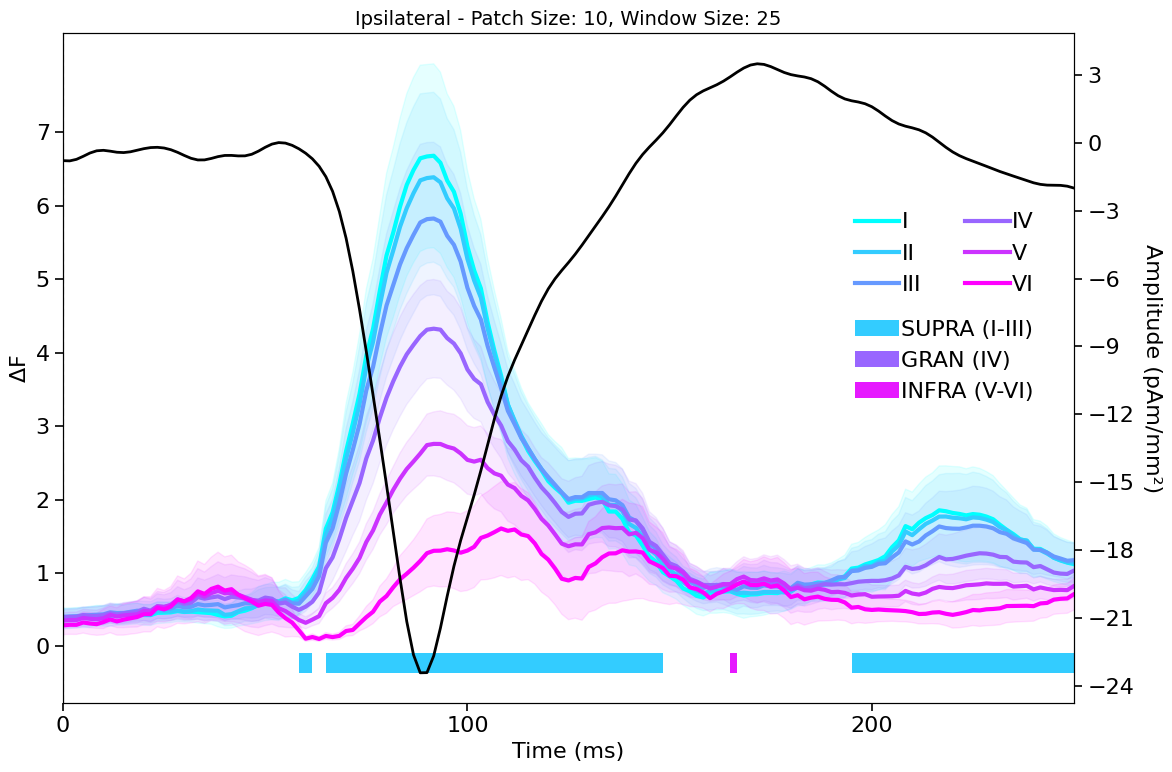

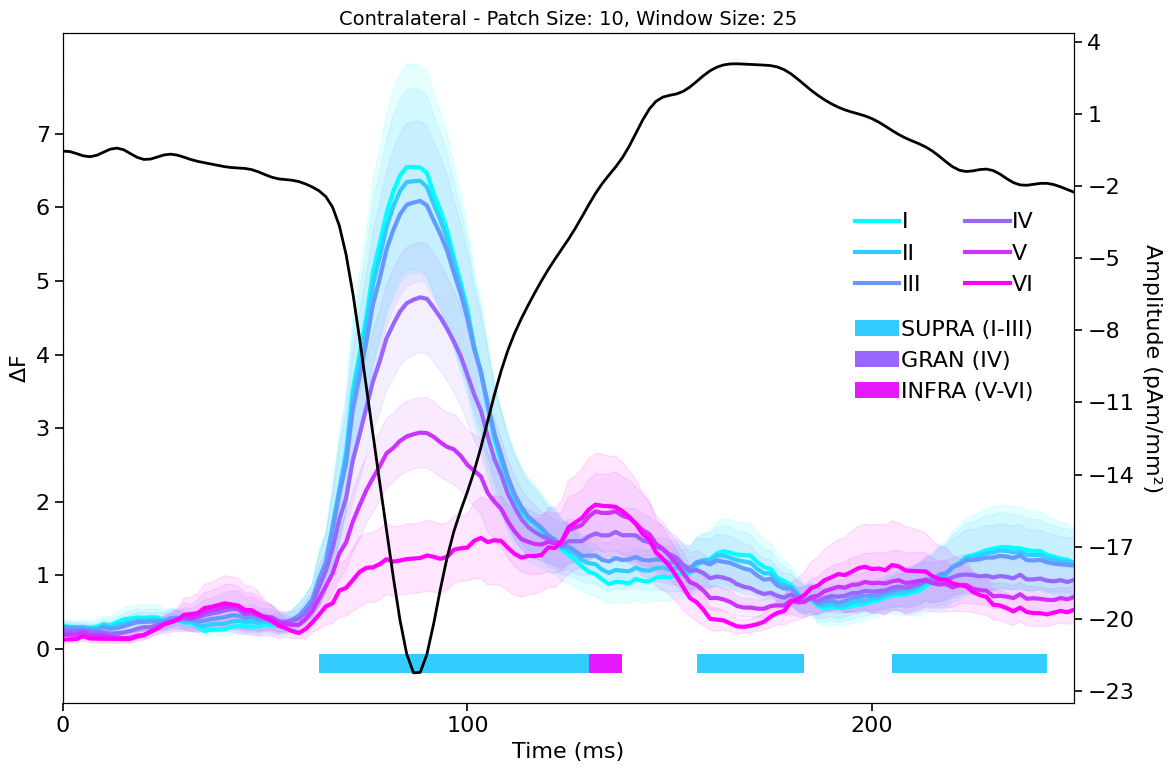

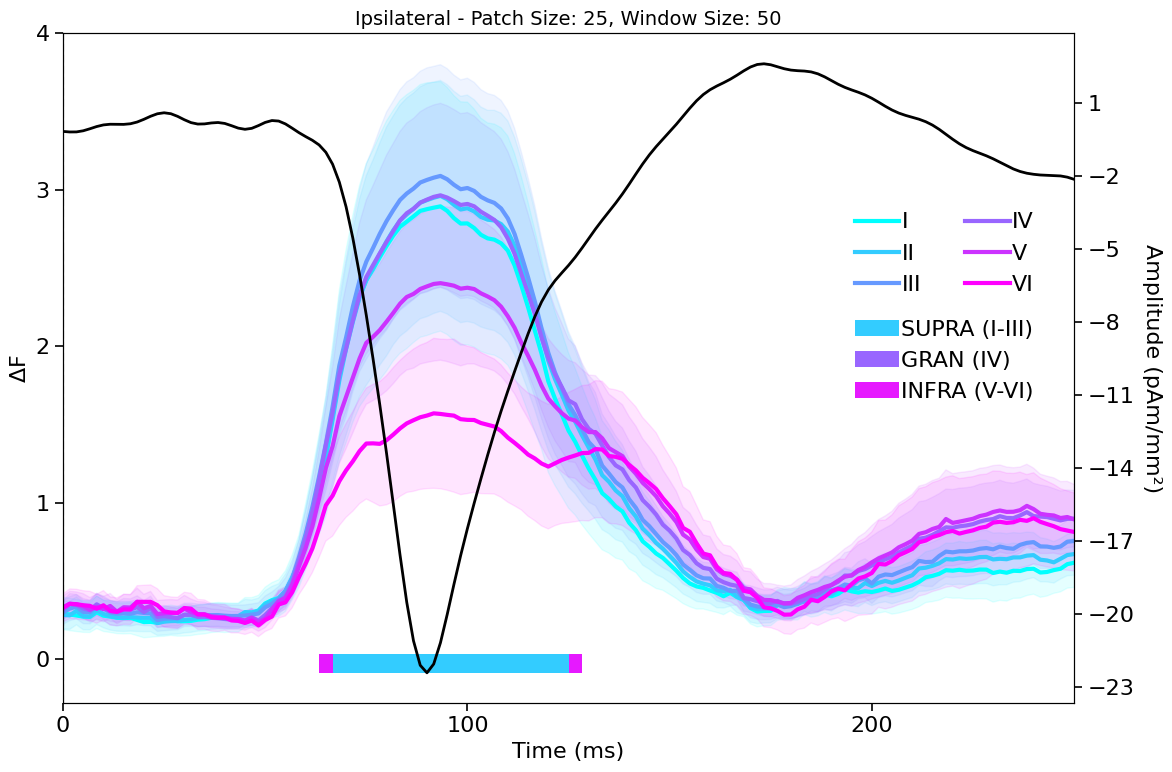

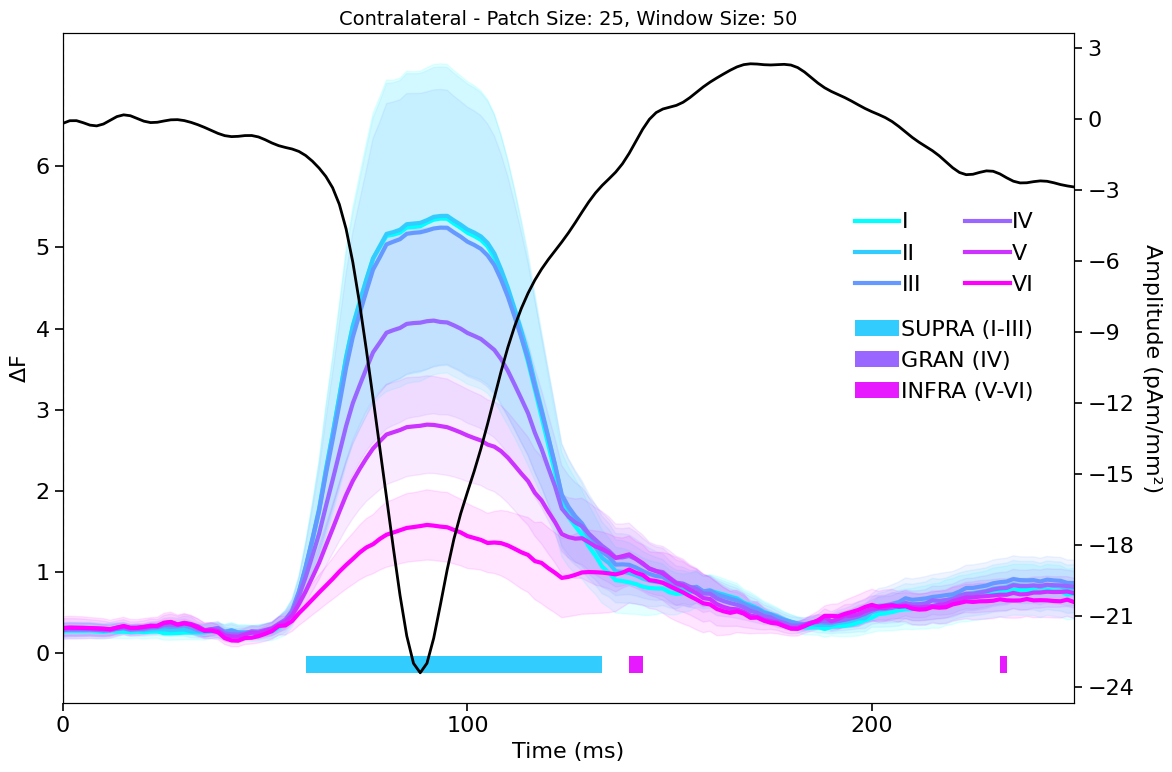

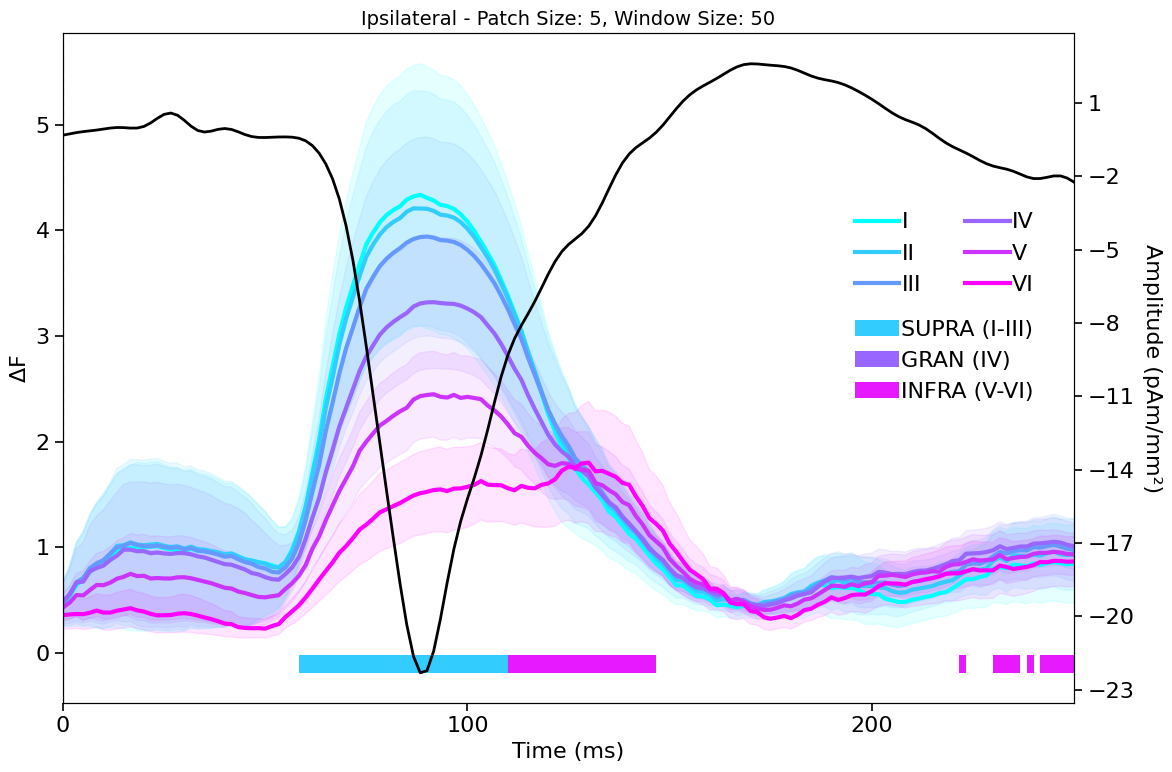

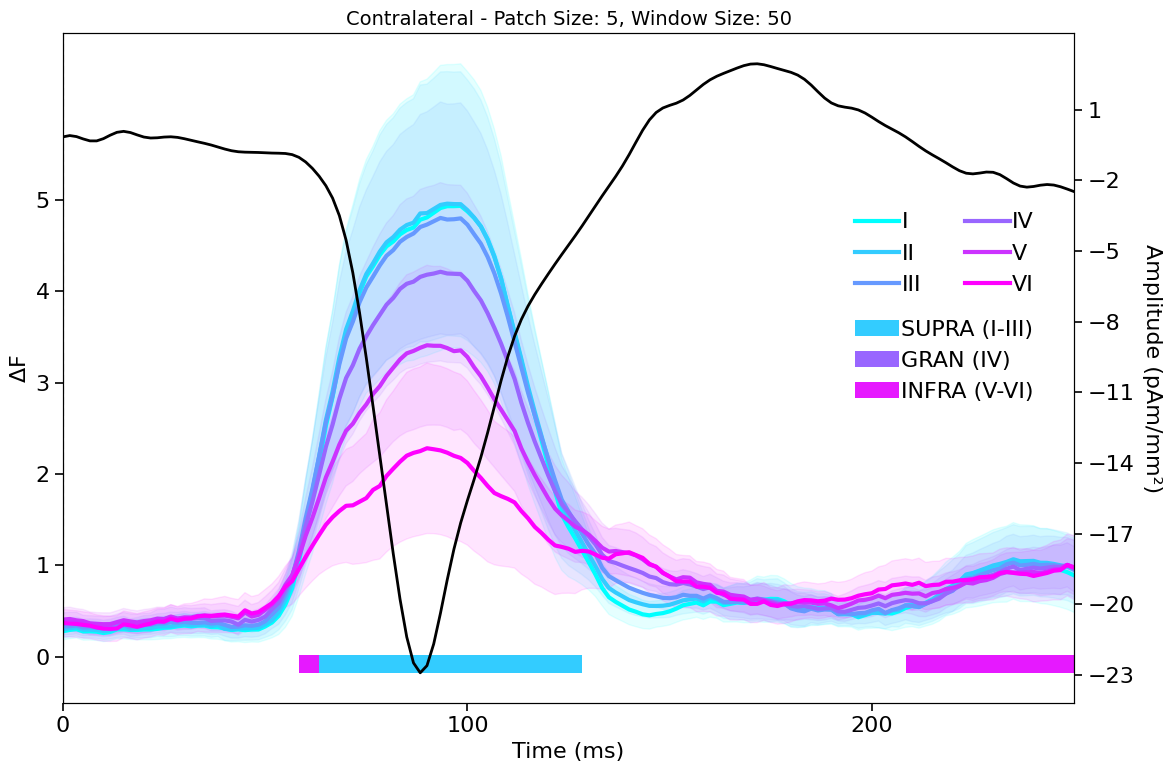

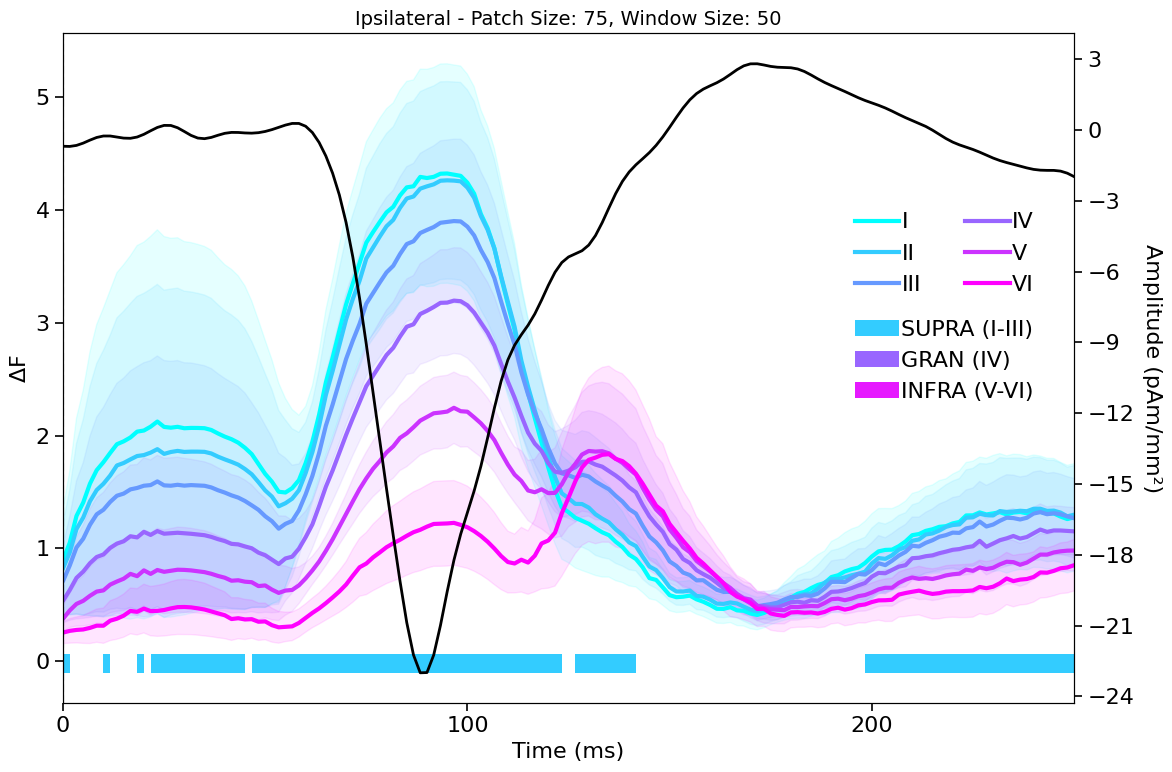

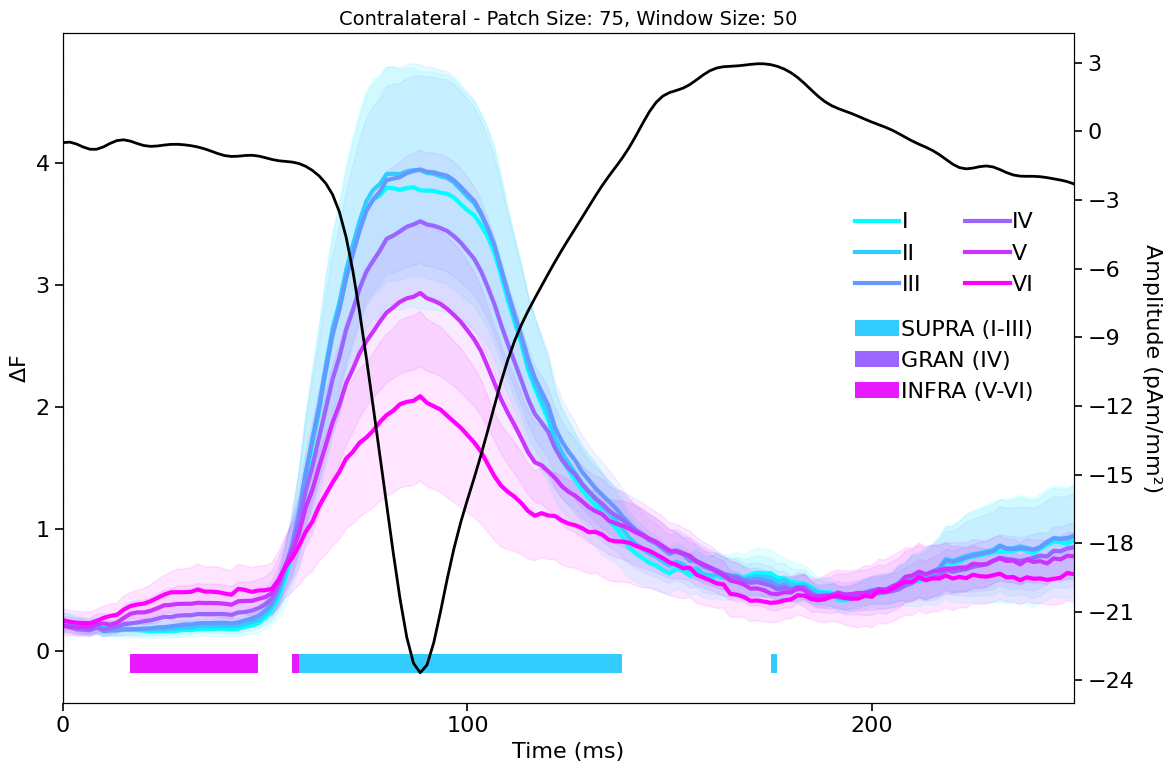

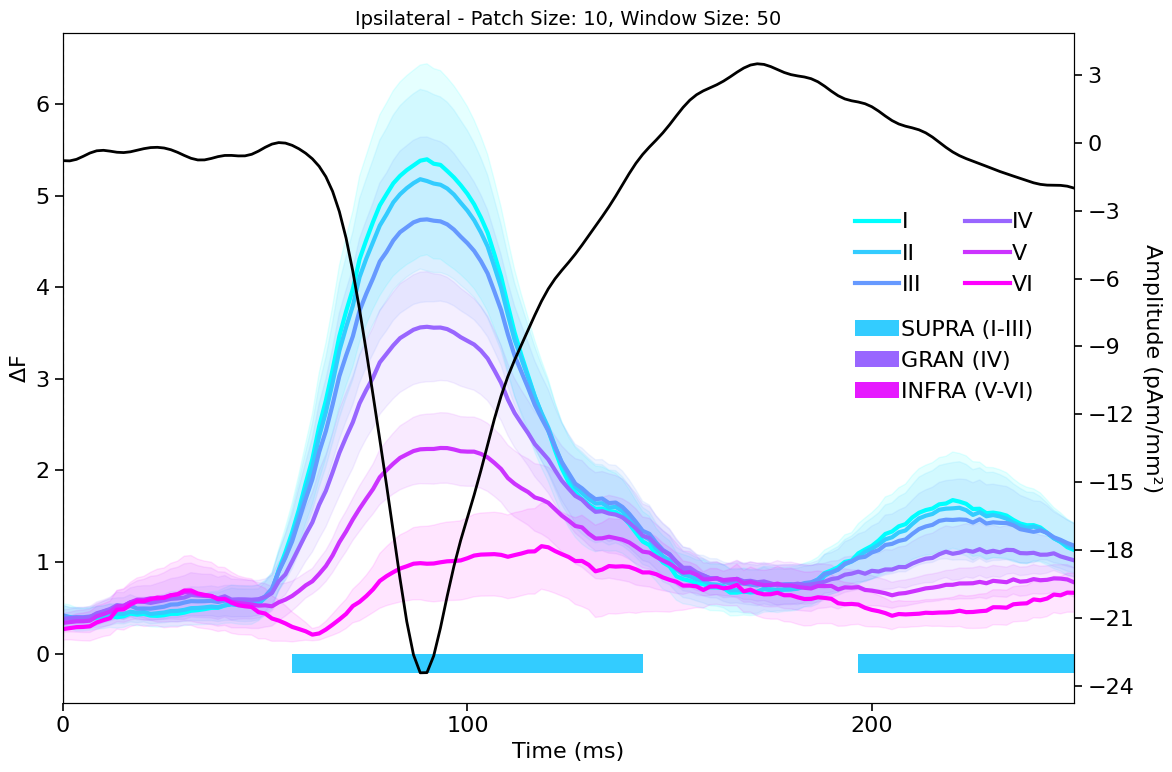

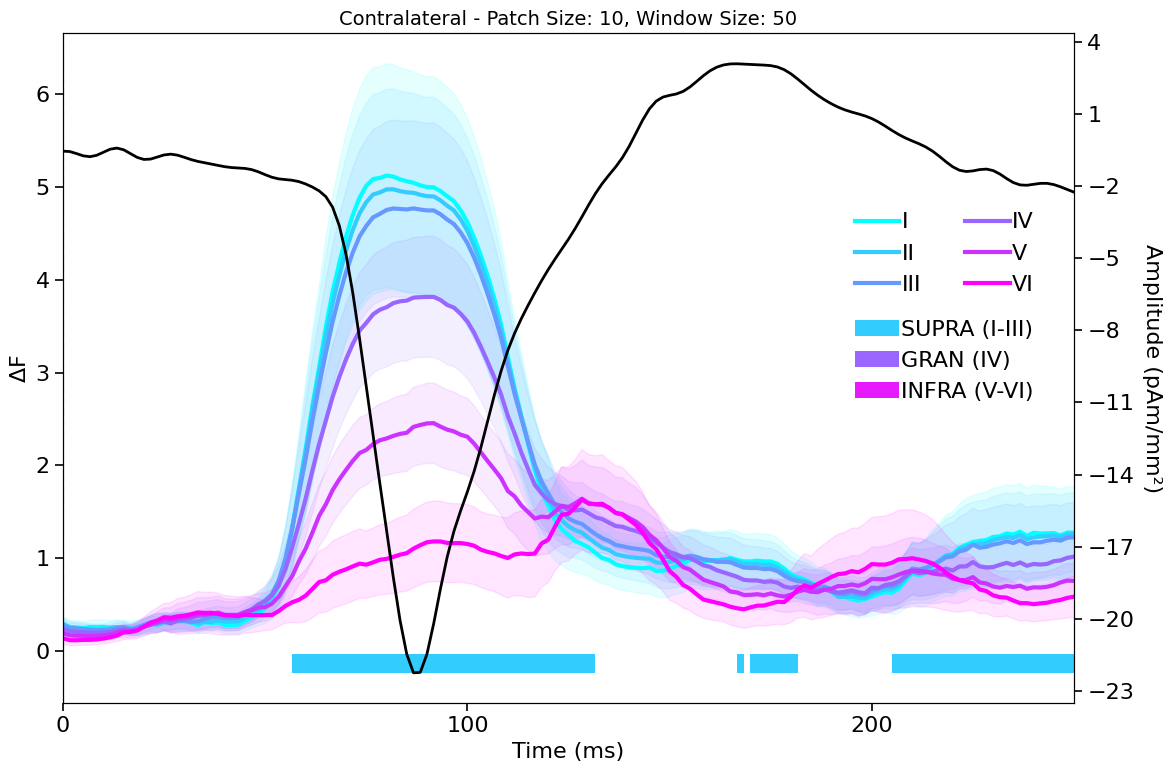

In [ ]:
n_layers = 11
vba_folder = "/home/membercophy/Matteo_M/V1_ERF/V1_ERF_F_diff"
savemat_folder = "/home/membercophy/Matteo_M/V1_ERF/V1_ERF_F_diff"
window_sizes = ["10", "25", "50"]
patch_sizes = ["25", "5", "75", "10",]
time_lims = [-300, 300]

col_l = plt.cm.cool(np.linspace(0, 1, num=6))
layer_colors = col_l
color_model_1 = layer_colors[0:3].mean(axis=0)
color_model_2 = layer_colors[3]
color_model_3 = layer_colors[4:6].mean(axis=0)
model_colors = {1: color_model_1, 2: color_model_2, 3: color_model_3}


l_labels = ['I', 'II', 'III', 'IV', 'V', 'VI']

for window in window_sizes:
    for patch in patch_sizes:
        mat_file = os.path.join(savemat_folder, f"ws{window}", f"ps{patch}", f'aligned_V1_ERF_FE_ws{window}_ps{patch}.mat')
        if not os.path.exists(mat_file):
            print(f"Skipping missing mat file: {mat_file}")
            continue

        data = sio.loadmat(mat_file)

        wois = data['wois']
        ts_time = data['ts_time'].squeeze()

        if np.max(np.abs(ts_time)) <= 1.0:
            ts_time = ts_time * 1000.0

        woi_win = ts_time

        la_aligned_lh_prior_ts = data['la_aligned_lh_prior_ts'] * 1000
        ra_aligned_rh_prior_ts = data['ra_aligned_rh_prior_ts'] * 1000
        la_aligned_lh_layer_F = data['la_aligned_lh_layer_F_diff']
        ra_aligned_rh_layer_F = data['ra_aligned_rh_layer_F_diff']

        la_aligned_rh_prior_ts = data['la_aligned_rh_prior_ts'] *1000
        ra_aligned_lh_prior_ts = data['ra_aligned_lh_prior_ts'] *1000
        la_aligned_rh_layer_F = data['la_aligned_rh_layer_F_diff']
        ra_aligned_lh_layer_F = data['ra_aligned_lh_layer_F_diff']

        conditions = [
            ("Ipsilateral", la_aligned_lh_prior_ts, ra_aligned_rh_prior_ts, 
             la_aligned_lh_layer_F, ra_aligned_rh_layer_F, f'ERF_OverTime_F_ipsi_family_ws{window}_ps{patch}.mat'),
            ("Contralateral", la_aligned_rh_prior_ts, ra_aligned_lh_prior_ts, 
             la_aligned_rh_layer_F, ra_aligned_lh_layer_F, f'ERF_OverTime_F_contra_family_ws{window}_ps{patch}.mat')
        ]

        for cond_name, ts1, ts2, layer_F1, layer_F2, vba_fname in conditions:
            if ts1.size == 0 or ts2.size == 0:
                continue

            combined_prior_ts = np.concatenate((ts1, ts2), axis=0)
            combined_layer_F = np.concatenate((layer_F1, layer_F2), axis=0)

            layer_F_diff = combined_layer_F - np.nanmin(combined_layer_F, axis=1, keepdims=True)

            m_prior_ts = np.mean(combined_prior_ts, axis=0)
            m_layer_F_diff = np.nanmean(layer_F_diff, axis=0)
            n_sub = layer_F_diff.shape[0]
            sem_layer_F_diff = np.nanstd(layer_F_diff, axis=0, ddof=1) / np.sqrt(n_sub)

            fig, ax = plt.subplots(figsize=(12, 8))

            layer_handles = []
            for i in range(6):
                line, = ax.plot(woi_win, m_layer_F_diff[i, :], label=f'{l_labels[i]}', color=col_l[i], linewidth=3)
                ax.fill_between(woi_win,
                                m_layer_F_diff[i, :] - sem_layer_F_diff[i, :],
                                m_layer_F_diff[i, :] + sem_layer_F_diff[i, :],
                                color=col_l[i], alpha=0.1)
                layer_handles.append(line)

            # Load VBA Model Evidence results & draw winning family bar
            vba_file_path = os.path.join(vba_folder, f"ws{window}", f"ps{patch}", vba_fname)
            if os.path.exists(vba_file_path):
                data_vba = sio.loadmat(vba_file_path)
                bestModelOverTime = data_vba['bestModelOverTime'].squeeze()

                mask_woi_vba = (ts_time >= woi_win[0]) & (ts_time <= woi_win[-1])
                time_woi_vba = ts_time[mask_woi_vba]
                model_woi = bestModelOverTime[mask_woi_vba]


                y_min = np.nanmin(m_layer_F_diff)
                y_max = np.nanmax(m_layer_F_diff)
                y_range = y_max - y_min

                y_model = y_min - (y_range * 0.05)

                bar_height = y_range * 0.04

                start_idx = 0
                for i in range(1, len(model_woi) + 1):
                    if i == len(model_woi) or model_woi[i] != model_woi[start_idx]:
                        model = model_woi[start_idx]
                        if model != 0:
                            t_start = time_woi_vba[start_idx]
                            t_end = time_woi_vba[i - 1]
                            ax.barh(y_model, width=t_end - t_start + np.median(np.diff(time_woi_vba)),
                                   left=t_start, color=model_colors[model], height=bar_height, align='center')
                        start_idx = i

            ax.axvline(x=0, color='k', linestyle='--', alpha=0.7)
            ax.set_xlabel('Time (ms)', fontname='Verdana', fontsize=16)
            ax.set_xticks(np.arange(0, 250, 100)) 

            ax.set_ylabel(r'$\Delta$F', fontname='Verdana', fontsize=16)
            y_min, y_max = int(np.floor(np.min(m_layer_F_diff))), int(np.ceil(np.max(m_layer_F_diff)))
            ax.set_yticks(np.arange(y_min, y_max + 1, 1))

            ax.set_title(f"{cond_name} - Patch Size: {patch}, Window Size: {window}", fontsize=14)

            model_handles = [
                Patch(facecolor=color_model_1, edgecolor='none', label='SUPRA (I-III)'),
                Patch(facecolor=color_model_2, edgecolor='none', label='GRAN (IV)'),
                Patch(facecolor=color_model_3, edgecolor='none', label='INFRA (V-VI)')
            ]

            
            leg2 = ax.legend(handles=model_handles, loc='lower right', bbox_to_anchor=(0.98, 0.42), frameon=False)
            ax.add_artist(leg2)
            leg1 = ax.legend(handles=layer_handles, loc='lower right', bbox_to_anchor=(0.98, 0.58), ncol=2, frameon=False)
            
            ax2 = ax.twinx()
            ax2.plot(ts_time, m_prior_ts, 'k', linestyle='-', linewidth = 2)
            y2_min, y2_max = int(np.floor(np.min(m_prior_ts))), int(np.ceil(np.max(m_prior_ts)))
            ax2.set_yticks(np.arange(y2_min, y2_max + 1, 3))

            ax2.set_ylabel('Amplitude (pAm/mm²)', rotation=-90, fontname='Verdana', fontsize=16, labelpad=20)
            ax.set_xlim([0, 250])
            plt.tight_layout()

            # Save Figure
            output_fig_dir = os.path.join(savemat_folder, "figures")
            os.makedirs(output_fig_dir, exist_ok=True)
            plt.savefig(os.path.join(output_fig_dir, f'V1_ERF_VBA_{cond_name}_ps{patch}_ws{window}.svg'), format='svg', bbox_inches='tight')
            
            plt.show()